# ***Flight Price Prediction using Machine Learning***

## 1. Introduction

### Objective
- Perform Exploratory Data Analysis (EDA)
- Build predictive models for flight price prediction
- Compare multiple machine learning models
- Identify the best model for deployment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## 2. Data Understanding

In [3]:
df.shape

(10683, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

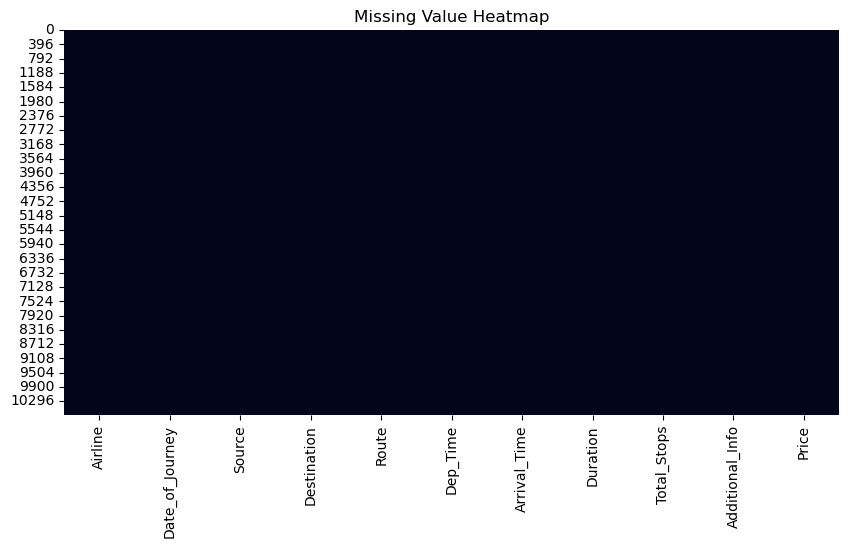

In [7]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

The heatmap shows that there are no missing values in the dataset, as all columns display a uniform color. This indicates that the dataset is complete and no missing value treatment is required before model building.

In [8]:
df.duplicated().sum()

220

In [9]:
df = df.drop_duplicates()

## 3. Feature Engineering

In [10]:
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.drop(["Date_of_Journey"], axis=1, inplace=True)

In [11]:
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop(["Arrival_Time"], axis=1, inplace=True)

In [12]:
duration = list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

df["Duration_hours"] = [int(i.split()[0][:-1]) for i in duration]
df["Duration_mins"] = [int(i.split()[1][:-1]) for i in duration]

df.drop(["Duration"], axis=1, inplace=True)

## 4. Exploratory Data Analysis (EDA)

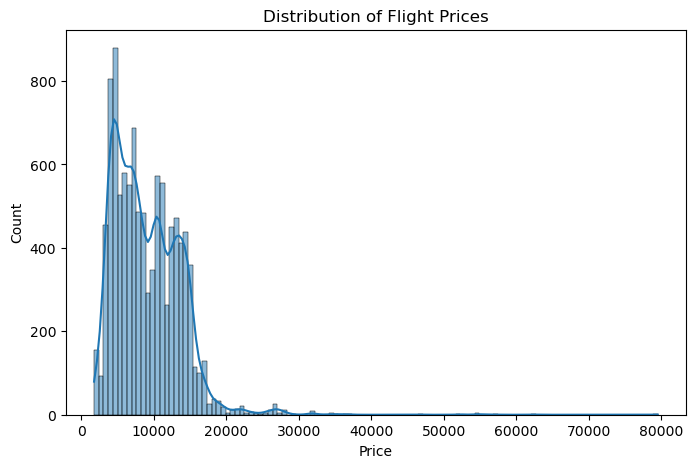

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of Flight Prices")
plt.show()

The price distribution is right-skewed with a few high-value outliers, which may represent premium or long-distance flights.

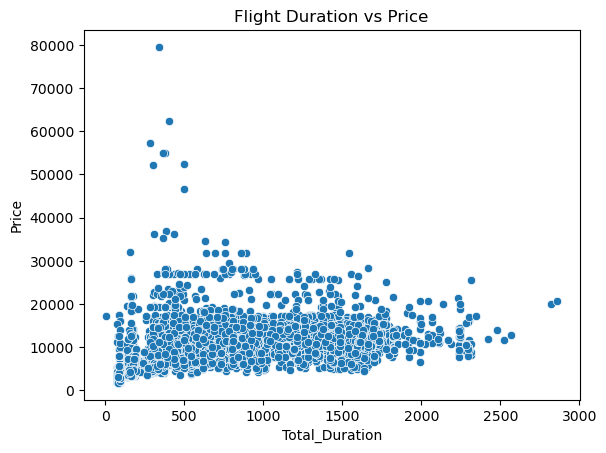

In [14]:
df["Total_Duration"] = df["Duration_hours"]*60 + df["Duration_mins"]

sns.scatterplot(x="Total_Duration", y="Price", data=df)
plt.title("Flight Duration vs Price")
plt.show()

Flight prices generally increase with longer travel durations, although some variation exists due to factors like number of stops, airline type, and route differences.

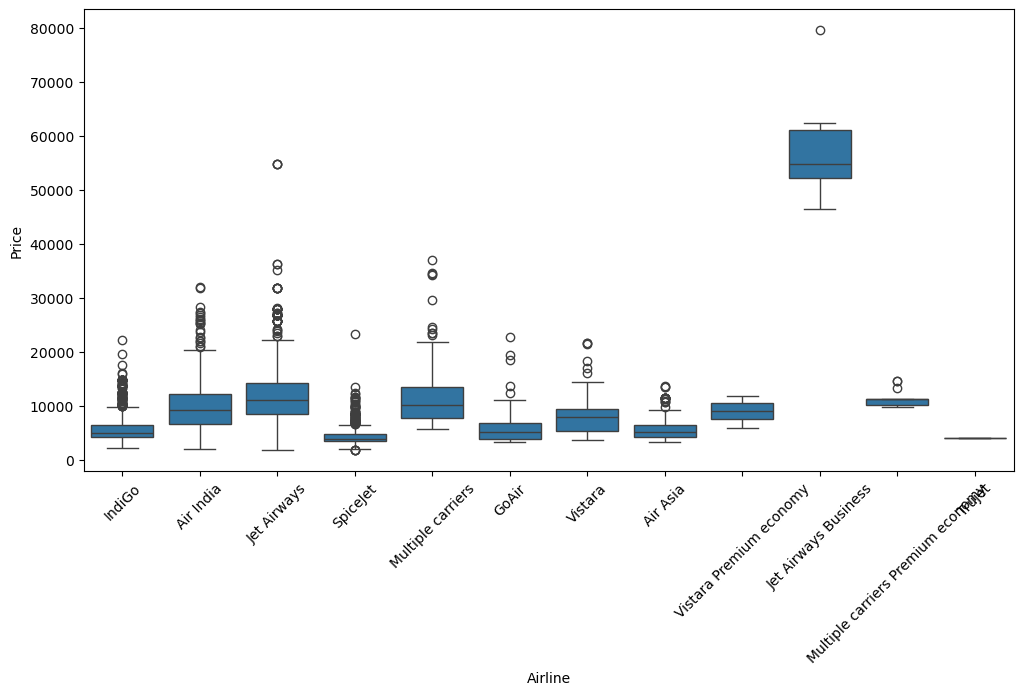

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=45)
plt.show()

Different airlines show varying price distributions.
Premium airlines tend to have higher median prices, while budget airlines offer lower fare ranges.

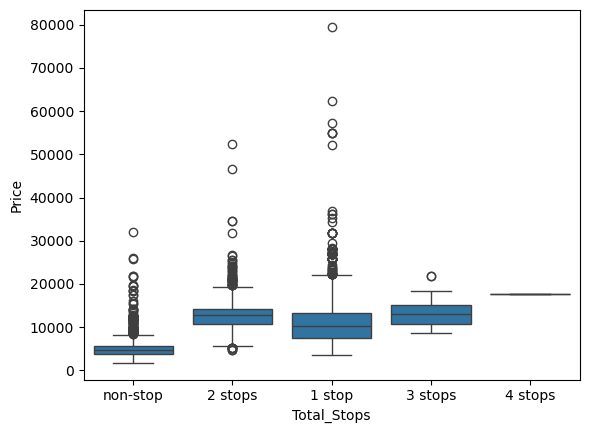

In [16]:
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.show()

Flights with more stops generally have lower ticket prices compared to direct flights, reflecting travel convenience differences.

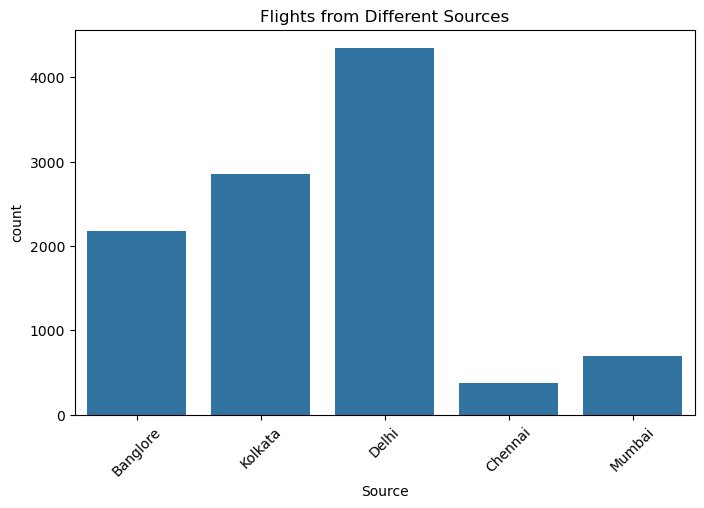

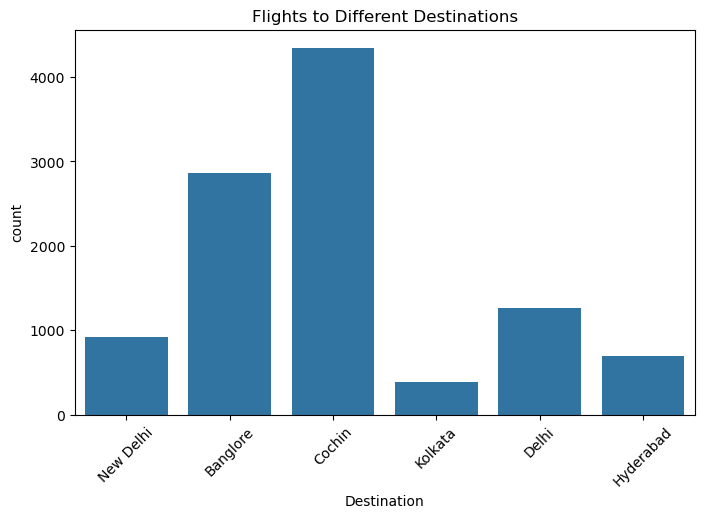

In [17]:
# Source Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x="Source", data=df)
plt.title("Flights from Different Sources")
plt.xticks(rotation=45)
plt.show()

# Destination Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x="Destination", data=df)
plt.title("Flights to Different Destinations")
plt.xticks(rotation=45)
plt.show()

Most flights originate from major cities like Delhi and Kolkata, indicating higher travel demand from these locations.

The majority of flights are directed towards major hubs such as Cochin and Delhi, reflecting common travel routes.

## 5. Encoding Categorical Variables

In [18]:
df = pd.get_dummies(df, drop_first=True)

## 6. Predictive Modeling

In [19]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied only to Linear Regression, as it is sensitive to feature magnitudes. Tree-based models such as Decision Tree and Random Forest are not affected by feature scaling, so unscaled data was used for these models.

In [22]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [23]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth":[5,10,15],
    "min_samples_split":[2,5,10]
}

dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [24]:
print("Best Parameters:", dt.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 2}


In [25]:
rf_params = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None]
}

rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [26]:
print("Best Parameters:", rf.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


## 7. Feature Importance Analysis

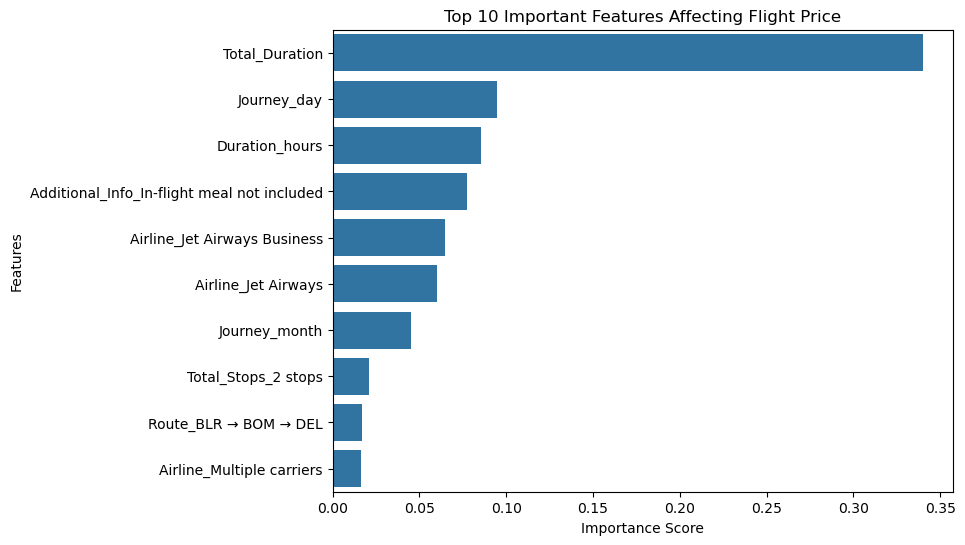

In [27]:
importances = rf.best_estimator_.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort and select top 10 features
top_features = feature_importance.sort_values(by="Importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=top_features)

plt.title("Top 10 Important Features Affecting Flight Price")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

The feature importance plot shows that the relative contribution of each feature in predicting the flight prices. Features like Total Stops, Airline, Duration, and Journey Month have a higher influence on ticket prices. This shows that the flight cost is significantly affected by the number of stops, airline brand, and travel duration. Understanding feature importance helps to interpret the model and identify the key factors that is impacting flight pricing.

In [28]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf.best_estimator_, X_train, y_train, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.92607873 0.83389756 0.88349151 0.90734175 0.888589  ]
Average CV Score: 0.8878797091612471


Cross-validation confirms that the model performs consistently across different subsets of the data, indicating good stability and generalization.

## 7. Model Comparison

In [29]:
def evaluate(y_test, pred):

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [30]:
results = pd.DataFrame({
"Model":["Linear Regression","Decision Tree","Random Forest"],
"MAE":[evaluate(y_test,pred_lr)[0],
       evaluate(y_test,pred_dt)[0],
       evaluate(y_test,pred_rf)[0]],

"RMSE":[evaluate(y_test,pred_lr)[1],
       evaluate(y_test,pred_dt)[1],
       evaluate(y_test,pred_rf)[1]],

"R2":[evaluate(y_test,pred_lr)[2],
       evaluate(y_test,pred_dt)[2],
       evaluate(y_test,pred_rf)[2]]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5.231641e+14,1.309273e+16,-8.215771e+24
1,Decision Tree,8.127915e+02,2.222331e+03,7.632960e-01
2,Random Forest,6.230380e+02,1.456095e+03,8.983827e-01


The Random Forest Regressor is the best among all models with the highest R² score and lowest prediction error. 

Random Forest typically performs best because:

- It captures non-linear relationships

- Reduces overfitting

- Handles complex feature interactions

The Decision Tree model showed signs of overfitting, as indicated by a high training score and lower testing score. However, the Random Forest model reduced overfitting through ensemble learning and achieved better generalization. Therefore, Random Forest was selected as the final model.

In [31]:
print("Training Score:", dt.score(X_train, y_train))
print("Testing Score:", dt.score(X_test, y_test))

Training Score: 0.969980381842827
Testing Score: 0.7632960231130361


The Decision Tree model showed slight overfitting, as the training performance was higher than the testing performance. However, the Random Forest model reduced overfitting through ensemble learning and achieved better generalization. This makes Random Forest the most suitable model for this problem.

## 8. Project Risks & Challenges
Key Risks

1 Data Quality Risk
Flight data may contain incorrect or outdated pricing information.

Mitigation:
Regular dataset validation and updates.

------

2 Market Dynamics
Airline pricing changes frequently due to demand and competition.

Mitigation:
Retrain the model periodically using new data.

------

3 Feature Limitations
Important factors like:
seat availability, demand and holidays, may not be included in the dataset.

Mitigation:
Integrate external datasets in future models

Challenges Faced

1. Date and time variables required feature extraction.
2. Duration column had inconsistent formats.
3. Categorical variables needed encoding.
4. Avoiding data leakage while applying scaling.
5. Selecting the best model among multiple algorithms.

## 9. Conclusion

In this project we successfully developed a machine learning model to predict flight ticket prices based on historical flight data.

EDA has revealed key relationships between airlines, stops, travel duration, and pricing.
After doing preprocessing and feature engineering, multiple regression models were trained and evaluated.

Among all the models tested, Random Forest Regressor achieved the best performance, as it has the lowest MSE and RMSE while achieved the highest R² score. This demonstrates the ability to capture complex relationships within the dataset.

With further enhancements like real-time data integration and advanced models, this can be improved for practical deployment in airline price prediction systems.

Although the Decision Tree model showed overfitting, the Random Forest model reduced this issue through ensemble learning. With hyperparameter tuning and cross-validation, the final model achieved strong predictive performance and good generalization capability.

The model achieved an R² score of approximately 0.76 on the test dataset, indicating good predictive performance.